<a href="https://colab.research.google.com/github/Dopmanius/repositorio/blob/main/Caso_de_uso_alternativo_(Proyecto_2)_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparación del Entorno y los Datos

Importación del dataframe

In [1]:
import pandas as pd
import requests
import io
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans

url = "https://raw.githubusercontent.com/Dopmanius/weather-data/cfe186327eb503ad5f82d12ce71176741486efae/weatherAUS.csv"  # URL raw del archivo en GitHub
weather_df = pd.read_csv(url)

#la url: descarga un archivo CSV desde GitHub y lo convierte en un DataFrame de pandas para su uso en Python.

**Consume datos relevantes del dataset (al menos 50 registros).**

In [ ]:
weather_df.head(51)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No
5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,...,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,0.0,No
6,2008-12-07,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,...,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No,0.0,No
7,2008-12-08,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,...,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,0.0,No
8,2008-12-09,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,...,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No,1.4,Yes
9,2008-12-10,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,S,...,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes,0.0,No


# Explorar a fondo la estructura del conjunto de datos.

In [ ]:
# Visualizar las primeras filas del DataFrame para entender la estructura de los datos
print("Primeras filas del DataFrame:")
print(df.head())

# Obtener información sobre las columnas, tipos de datos y valores nulos
print("\nInformación del DataFrame:")
print(df.info())

# Descripción estadística del dataset para características numéricas
print("\nDescripción estadística del DataFrame:")
print(df.describe())

Primeras filas del DataFrame:
         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity3pm  Pressure9am  \
0           W           44.0          W  ...        22.0       1007.7   
1         WNW           44.0        NNW  ...        25.0       1010.6   
2         WSW           46.0          W  ...        30.0       1007.6   
3          NE           24.0         SE  ...        16.0       1017.6   
4           W           41.0        ENE  ...        33.0       1010.8   

   Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  RIS

In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


**El conjunto de datos weatherAUS.csv contiene información meteorológica recopilada en Australia. Cada fila representa un día y las columnas incluyen datos como temperatura mínima y máxima, cantidad de lluvia, dirección y velocidad del viento, humedad, presión atmosférica, entre otros. La columna "RainTomorrow" es la variable objetivo que indica si lloverá al día siguiente, mientras que "RainToday" indica si llovió durante el día actual.**

# Identificar y analizar los tipos de datos de cada columna

In [ ]:
# Identificar y analizar los tipos de datos de cada columna
tipos_de_datos = df.dtypes
print("Tipos de datos de cada columna:")
print(tipos_de_datos)

Tipos de datos de cada columna:
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RISK_MM          float64
RainTomorrow      object
dtype: object


# Explorar y Limpiar los Datos

**Verificar si existen nulos en la columnas**

In [ ]:
weather_df.isna().any()

,0
Date,False
Location,False
MinTemp,True
MaxTemp,True
Rainfall,True
Evaporation,True
Sunshine,True
WindGustDir,True
WindGustSpeed,True
WindDir9am,True


**Contador de datos nulos por columna**

In [ ]:
nulos_por_columna = weather_df.isnull().sum()
print(nulos_por_columna)

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64


**Drop de columnas con demasiados valores nulos o de tipo object**

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer

weather_df.drop(columns=['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm', 'RainToday',
                         'Date', 'Location','WindGustDir','WindDir9am','WindDir3pm'], inplace=True)

num_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
            'Humidity9am', 'Humidity3pm', 'Temp9am', 'Temp3pm', 'Pressure9am', 'Pressure3pm']

# Imputar valores nulos en columnas numéricas con la media
num_imputer = SimpleImputer(strategy='mean')
weather_df[num_cols] = num_imputer.fit_transform(weather_df[num_cols])

nulos_por_columna = weather_df.isnull().sum()
print(nulos_por_columna)

MinTemp          0
MaxTemp          0
Rainfall         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RISK_MM          0
RainTomorrow     0
dtype: int64


**histograma de la variable independiente (MaxTemp)**

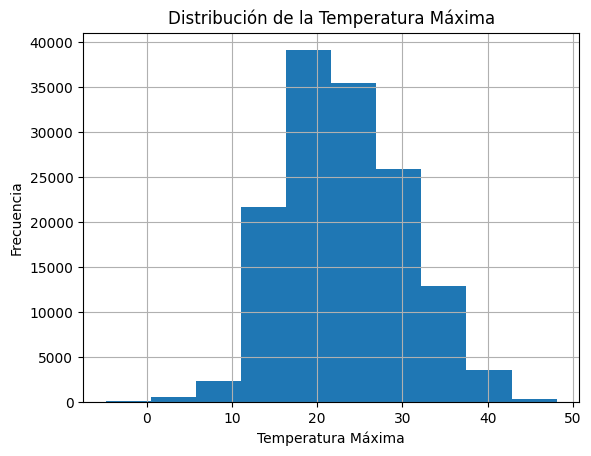

In [ ]:
import matplotlib.pyplot as plt

# Crear un histograma de la variable independiente (MaxTemp)
df['MaxTemp'].hist()

# Personalizar la visualización
plt.xlabel('Temperatura Máxima')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Temperatura Máxima')
plt.show()

# Objetivo: Desarrollar un modelo que permita predecir la cantidad y distribución de las precipitaciones en Australia. Esto podría ayudar en la planificación agrícola, la gestión del agua y la preparación para eventos de inundaciones.

**Calcular estadísticas básicas de la variable dependiente u objetivo, en nuestro caso se seleccionó "RainTomorrow"**

In [ ]:
# Calcular estadísticas básicas de la variable dependiente
estadisticas = df['RainTomorrow'].describe()
print(estadisticas)

count     142193
unique         2
top           No
freq      110316
Name: RainTomorrow, dtype: object


In [ ]:
 print(df.groupby('RainTomorrow').size())

RainTomorrow
No     110316
Yes     31877
dtype: int64


# **Mostrar porcentajes de los datos "Yes" o "No" de la columna "RainTomorrow"**

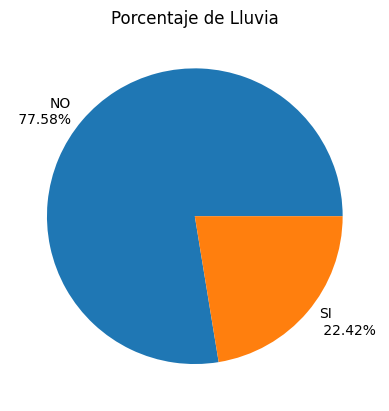

In [ ]:
clases = np.array([df[df.RainTomorrow == 'No'].shape[0],
                   df[df.RainTomorrow == 'Yes'].shape[0]])


labels = [str(round(x * 1.0 / clases.sum() * 100.0, 2)) + '%' for x in clases]
labels[0] = 'NO\n ' + labels[0]
labels[1] = 'SI\n ' + labels[1]

plt.pie(clases, labels=labels)
plt.title('Porcentaje de Lluvia')
plt.show()

# **Como variable objetivo para la construccion del algoritmo supervisado se utilizara la columna ¨RainTomorrow¨. Se usará el enfoque de etiqueta codificada para asignar un valor númerico de 1 y 0 a los valores de Yes o No respectivamente.**

In [ ]:
# Ver detalles de la columna RainTomorrow para comprobar si existe algún Outlier
df.groupby('RainTomorrow').size()

,0
RainTomorrow,
No,110316
Yes,31877


In [ ]:
# Calcula el número total de categorías únicas en 'RainTomorrow'
total = df['RainTomorrow'].nunique()

# Crea un diccionario que mapee las categorías únicas a valores numéricos diferentes
d_categoria = dict(zip(df['RainTomorrow'].unique(), range(total)))  # Comenzando desde 0

# Agrega una nueva columna 'categoria' al DataFrame utilizando el mapeo
df['categoria'] = df['RainTomorrow'].map(d_categoria)

# Muestra las primeras filas del DataFrame
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow,categoria
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No,0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No,0
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No,0
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No,0
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No,0


# **Análisis de Variables Independientes (una variable y más de una variable):**

Las variables independientes "WindGustSpeed", "Humidity3pm" y "Pressure9am" fueron seleccionadas para el modelo supervisado basándose en su relevancia teórica y práctica para predecir la probabilidad de lluvia.

WindGustSpeed (Velocidad de Ráfaga de Viento): La velocidad máxima del viento puede influir en la formación de sistemas atmosféricos que traen consigo lluvia. Ráfagas de viento más fuertes pueden estar asociadas con cambios en la circulación atmosférica que favorecen la precipitación.

Humidity3pm (Humedad a las 3pm): La humedad relativa del aire a las 3 de la tarde es un indicador importante de la cantidad de vapor de agua presente en la atmósfera. Altos niveles de humedad pueden aumentar la probabilidad de formación de nubes y precipitación.

Pressure9am (Presión a las 9am): La presión atmosférica a las 9 de la mañana puede proporcionar información sobre la estabilidad atmosférica y los sistemas meteorológicos en desarrollo. Cambios en la presión atmosférica pueden estar asociados con cambios en el clima, incluida la ocurrencia de lluvia.
Estas variables fueron seleccionadas porque representan aspectos clave del sistema climático que pueden influir en la probabilidad de lluvia, proporcionando una base sólida para la construcción del modelo supervisado de predicción.

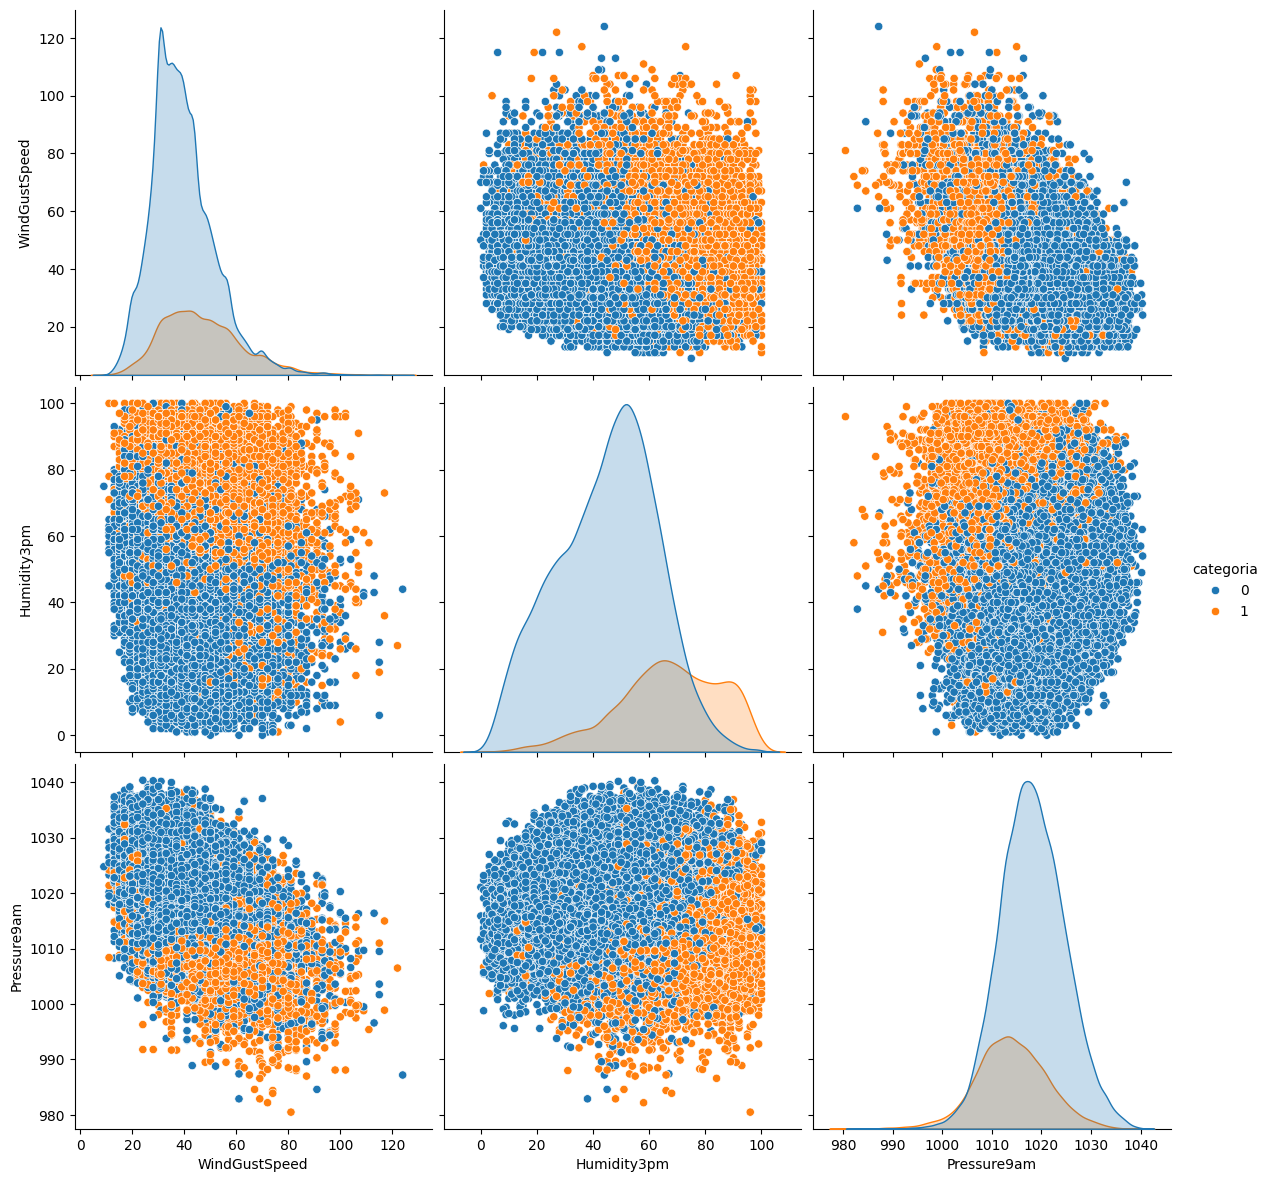

In [ ]:
sns.pairplot(df.dropna(), hue='categoria',height=4,vars=["WindGustSpeed","Humidity3pm","Pressure9am"],kind='scatter')

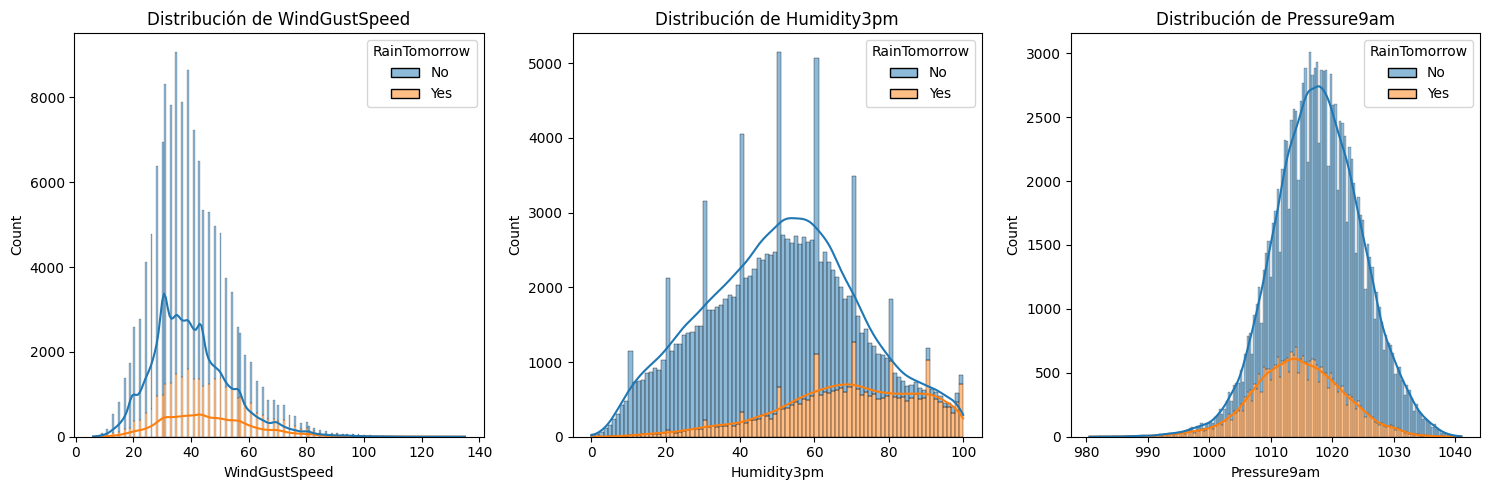

In [ ]:
# Gráficos de distribución para explorar la distribución de las variables independientes

# Seleccionar las variables independientes y la variable objetivo
variables_independientes = ["WindGustSpeed","Humidity3pm","Pressure9am"]
variable_objetivo = 'RainTomorrow'

# Crear subplots para cada variable independiente
fig, axes = plt.subplots(nrows=1, ncols=len(variables_independientes), figsize=(15, 5))

# Iterar sobre cada variable independiente y crear el gráfico de distribución
for i, variable in enumerate(variables_independientes):
    sns.histplot(data=df, x=variable, hue=variable_objetivo, ax=axes[i], kde=True, multiple="stack")
    axes[i].set_title(f'Distribución de {variable}')
    axes[i].set_xlabel(variable)

# Mostrar los gráficos
plt.tight_layout()
plt.show()

# **Visualizacion de los datos, antes de la segmentación**

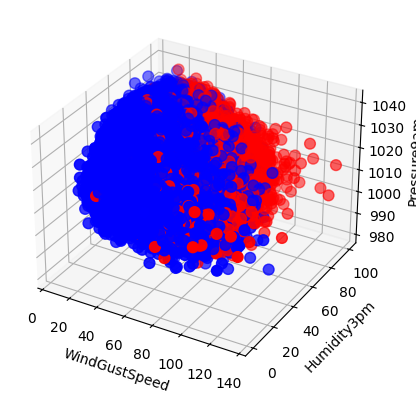

In [ ]:
# Limpieza de datos
df_cleaned = df.dropna(subset=['WindGustSpeed', 'Humidity3pm', 'Pressure9am'])

X = np.array(df_cleaned[["WindGustSpeed", "Humidity3pm", "Pressure9am"]])
y = np.array(df_cleaned['categoria'])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')  # Añade un subplot 3D

# Asignar colores según los valores de la variable objetivo.
colores = ['blue', 'red']
asignar = [colores[val] for val in y]

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=asignar, s=60)

# Etiquetas de los ejes
ax.set_xlabel('WindGustSpeed')
ax.set_ylabel('Humidity3pm')
ax.set_zlabel('Pressure9am')

plt.show()

**Este gráfico muestra una representación tridimensional de los datos antes de la limpieza. Los ejes x, y, z representan las variables "WindGustSpeed" (Velocidad de Ráfaga de Viento), "Humidity3pm" (Humedad a las 3pm) y "Pressure9am" (Presión a las 9am), respectivamente. Cada punto en el gráfico representa una observación del conjunto de datos limpiado**

# **Contruccion del modelo supervisado**

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

df_cleaned = df.dropna(subset=['WindGustSpeed', 'Humidity3pm', 'Pressure9am'])

X = np.array(df_cleaned[["WindGustSpeed", "Humidity3pm", "Pressure9am"]])
y = np.array(df_cleaned['categoria'])

fig = plt.figure()
ax = Axes3D(fig)

# Asignar colores según los valores de la variable objetivo.
colores = ['blue', 'red']
asignar = [colores[val] for val in y]

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=asignar, s=60)
plt.show()


<Figure size 640x480 with 0 Axes>

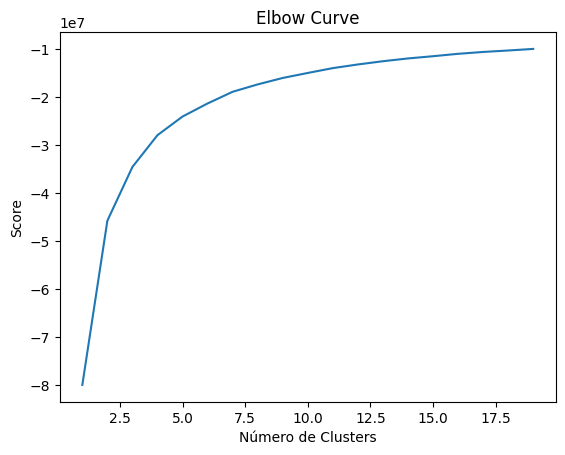

In [ ]:
from sklearn.cluster import KMeans
num_clusters = range(1, 20)
kmeans = [KMeans(n_clusters=i) for i in num_clusters]
kmeans
score = [kmeans[i].fit(X).score(X) for i in range(len(kmeans))]
score
plt.plot(num_clusters,score)
plt.xlabel('Número de Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

**Si observamos la gráfica podemos observar el punto donde la curva comienza a aplanarse esto nos ayuda a determinar que el número óptimo de clusters es 2.**

# **Se ejecuta el algoritmo para 2 clusters y se obtienen las etiquetas y los centroids.**

In [ ]:
kmeans = KMeans(n_clusters=2).fit(X)
centroids = kmeans.cluster_centers_
print(centroids)

[[  39.25800245   66.64559574 1017.65672392]
 [  41.07512152   32.98638975 1017.65791074]]


# **Se elabora grafico en 2 dimensiones para que ayude a visualizar los grupos y su clasificación**

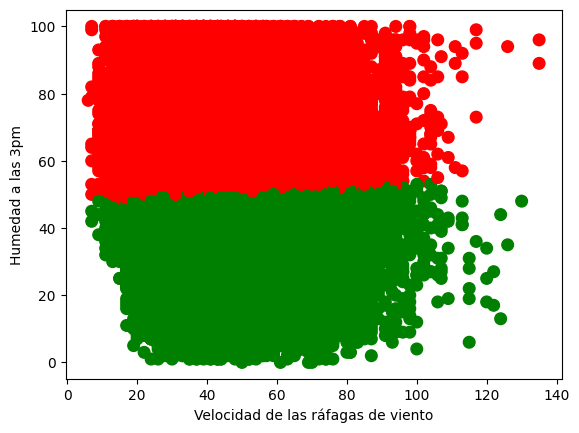

In [ ]:
labels = kmeans.predict(X)

# Getting the cluster centers
C = kmeans.cluster_centers_

# 2 colores porque k = 2
colores=['red','green']
asignar=[]
for row in labels:
  asignar.append(colores[row])

f1 = df_cleaned["WindGustSpeed"].values
f2 = df_cleaned["Humidity3pm"].values
plt.scatter(f1, f2, c=asignar, s=70)
plt.scatter(C[:, 0], C[:, 1], marker='*', c=colores, s=1000)
plt.xlabel("Velocidad de las ráfagas de viento")
plt.ylabel("Humedad a las 3pm")
plt.show()

# **Analisis de Correlacion**

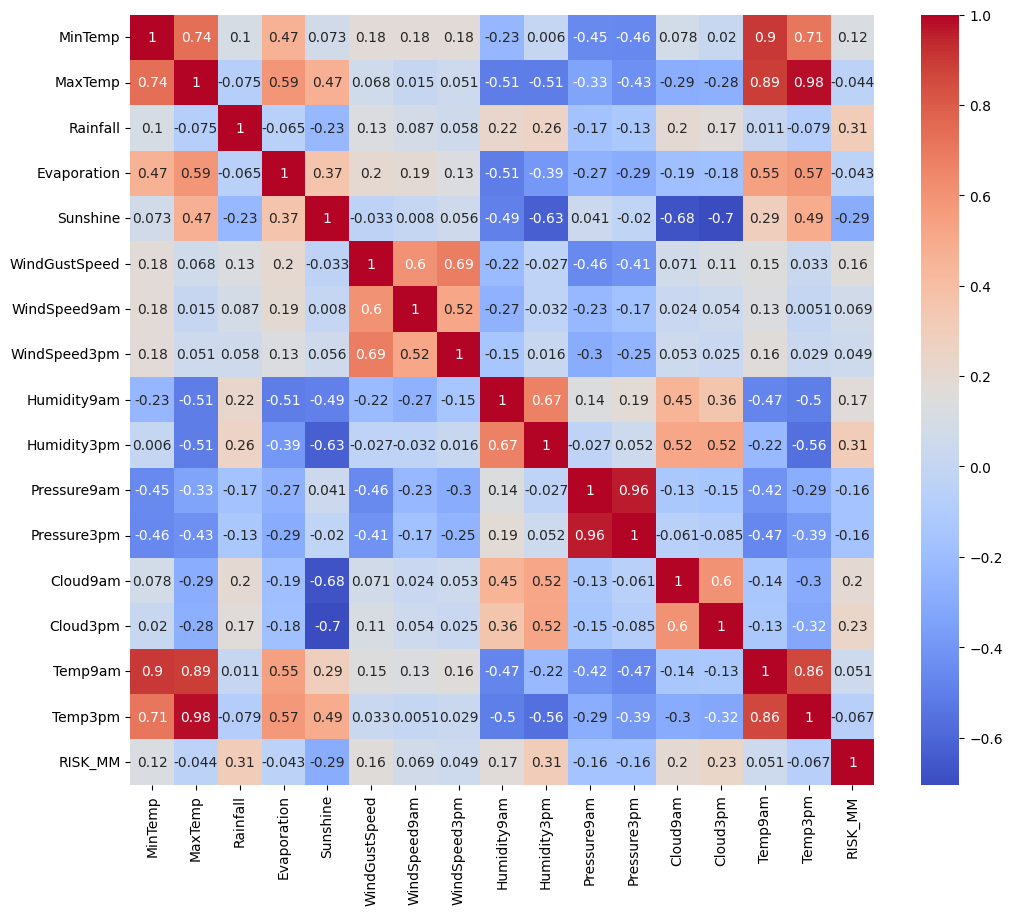

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ... (código para calcular la matriz de correlación) ...

# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 10))  # Ajusta los valores (12, 10) según tus preferencias

# Generar el mapa de calor
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

# Mostrar el gráfico
plt.show()

# **Modelo No Supervisado**

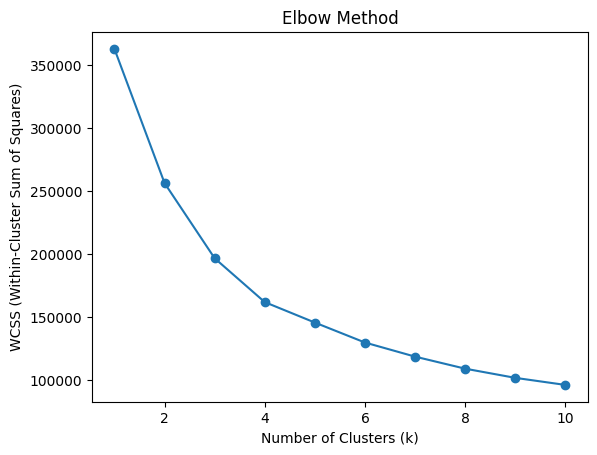

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Create a range of cluster numbers
cluster_range = range(1, 11)  # Assuming you tested clusters from 1 to 10

# Plot WCSS vs. number of clusters
plt.plot(cluster_range, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.show()

**Este código visualiza el método del codo para determinar el número óptimo de clústeres en un algoritmo de agrupamiento K-Means. Grafica el WCSS (suma de cuadrados dentro del clúster) contra el número de clústeres, buscando el "codo" en la gráfica. Este punto de inflexión representa el número ideal de clústeres, donde agregar más no reduce significativamente el WCSS.**

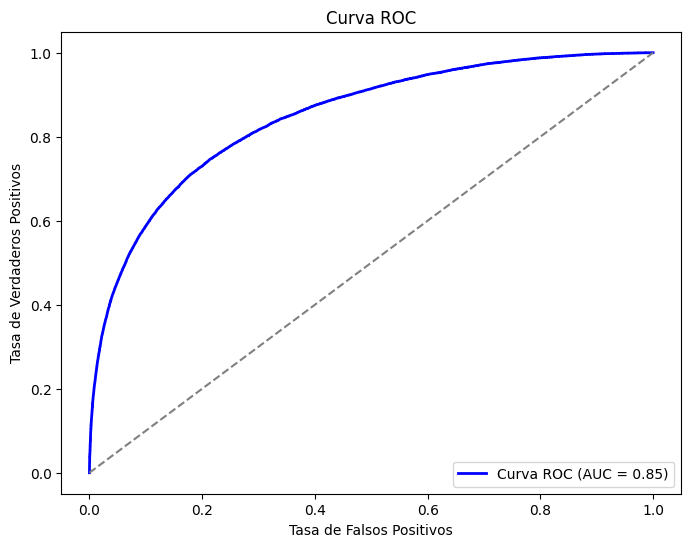

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_predict, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt



# 3. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Apply scaling on all the data (X)
X_train_scaled = scaler.transform(X_train)  # Apply scaling to X_train
X_test_scaled = scaler.transform(X_test) # Apply scaling to X_test

# 5. Create and Train Logistic Regression Model
logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled, y_train)  # Train on scaled training data

# 6. Cross-Validation and ROC Curve
# Create KFold or StratifiedKFold object
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get probabilities
y_probabilities = cross_val_predict(logistic_model, X_scaled, y, cv=kf, method='predict_proba')

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y, y_probabilities[:, 1])
roc_auc = auc(fpr, tpr)

# 7. Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for reference
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

El modelo de regresión logística evaluado utilizando validación cruzada muestra un desempeño aceptable. Utilizando validación cruzada estratificada con 5 divisiones, se calculó el valor promedio del área bajo la curva ROC (AUC), resultando en 0.85. Este valor indica que el modelo tiene una buena capacidad para distinguir entre las clases, demostrando un rendimiento sólido en términos de discriminación.

Además, los resultados de la curva ROC muestran una tasa de verdaderos positivos notablemente mayor en comparación con los falsos positivos a lo largo de diferentes umbrales de decisión. Esto sugiere que el modelo es eficiente al predecir correctamente las instancias positivas.